## Fine-tuning
A series of experiments to fine tune the model. The goal is to improve validation accuracy even further.


#### Experiments
**Learning Rate**
1. ✅ Learning Rate Finder  
Identify an optimal learning rate range by gradually increasing it and tracking the loss.
2. ✅ Learning Rate Scheduler  
Apply a learning rate schedule to improve training.

**Leave it training**
3. ✅ Train for more epochs with a large learning rate
lr=1e-3, epochs=300
4. ✅ Train for more epochs with an inital large learning rate
lr=1e-3, and a learning rate scheduler with exponetial decay, epochs=300
* Train with lr=1e-3, and a learning rate scheduler with exponetial decay, epochs=350, use ModelCheckpoint to save best model

#### Performance of best model from regularization
**Validation:**  
Epoch 100/100
val_accuracy: 0.8295 - val_binary_io_u: 0.6840 - val_binary_io_u_1: 0.7917 - val_loss: 0.0937 - val_precision: 0.8461 - val_recall: 0.9248

**Test:**  
Loss: 0.0958  
Accuracy: 0.7950  
Precision: 0.8673  
Recall: 0.8592  
F1 Score: 0.8633  
Mean IoU: 0.7017   
IoU for class 1: 0.7594  
AUC: 0.8243  


## Setup
Set up file system for the datset(using Google Drive), dagshub and MLflow

In [1]:
# Install dependencies
%%capture
%pip install -q dagshub[jupyter]
!pip install mlflow
!pip install rasterio
!pip install natsort

# Suppress warnings
import logging
logging.getLogger("rasterio").setLevel(logging.ERROR)

In [2]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# Set up dagshub
!dagshub login
import dagshub
TOKEN = dagshub.auth.get_token()

Mounted at /content/drive
                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=b1dc48a1-a083-492e-8917-d1cf863becb0&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=f231570e1c0d7ce8aa210a94beaaa2f212134b4cd0e6b784abec10f3352da59b


⠴ Waiting for authorization
✅ OAuth token added


Accessing as chengzwk

## Data Preparation

In [3]:
# Import packages
import os
import sys
import rasterio
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from natsort import natsorted
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


def print_progress_bar(iteration, total, length=40):
    """Print a progress bar."""
    percent = (iteration / total) * 100
    filled_length = int(length * iteration // total)
    bar = '█' * filled_length + '-' * (length - filled_length)
    sys.stdout.write(f'\r|{bar}| {percent:.2f}%')
    sys.stdout.flush()

def normalize_by_layer(image_array):
    """
    Function to normalize image data to the same max(1) and min(0)
    Since different layers(bands) have different scales, normalization will be done layer by layer
    """
    # Normalize by band
    image_array = image_array.astype(np.float64)  # Convert dtype of image file from int to float64

    for i in range(image_array.shape[2]):
        layer_min = np.min(image_array[:, :, i])
        layer_max = np.max(image_array[:, :, i])

        try:
            image_array[:, :, i] = (image_array[:, :, i] - layer_min) / (layer_max - layer_min)
        except ZeroDivisionError:
            print(f"Band {i} has zero variation (min = max = {layer_min}). Skipping normalization.")
            image_array[:, :, i] = 0  # Set the band to default value 0

    return image_array

def convert_binary_mask(mask_array, multiclass=True, threshold=0.5):
    """
    Convert fractional mask to binary mask
    By default, convert it to multiclass mask of 5 classes
    Class numbers:
    0: Impervious surfaces and buildings
    1: Low vegetation
    2: Trees
    3: Water
    4: Clutter/Background
    """
    if multiclass:
        mask_array = np.argmax(mask_array, axis=2, keepdims=True)
    else:
        mask_array = ((mask_array[:, :, 1] + mask_array[:, :, 2]) >= threshold).astype(np.uint8)
        mask_array = mask_array[:, :, np.newaxis]
    return mask_array

def read_file(data_dir, image_dir, multiclass=True, threshold=0.5, subset_size=None):
    """
    Read satellite image files and corresponding masks as numpy arrays,
    normalize image array to the same scale by band, and convert fractional masks into binary masks.
    Read subset_size image files for training
    Note we're only using images from the same time (files ends in 1_GeoTIFF)
    """
    image_dataset = []
    mask_dataset = []
    mask_dir = image_dir + '_masks'
    image_files = [f for f in os.listdir(os.path.join(data_dir, image_dir)) if f.endswith('1_GeoTIFF.tif')]
    image_files = natsorted(image_files)
    if subset_size is not None:
        image_files = image_files[:subset_size]
    total_files = len(image_files)

    # Print progress
    print(f"Reading images and masks from {image_dir} and {mask_dir}")

    for i, image_file in enumerate(image_files):
        mask_file = image_file.replace('.tif', '_fractional_mask.tif')
        image_path = os.path.join(data_dir, image_dir, image_file)
        mask_path = os.path.join(data_dir, mask_dir, mask_file)

        # Read image file
        with (rasterio.open(image_path) as img):
            image_array = img.read()
        image_array = np.transpose(image_array, [1, 2, 0])  # move the axis for bands to the third axis
        image_array[np.isnan(image_array)] = 0                   # replace nan with 0
        image_array = image_array[:, :, (1, 2, 3)]               # get the bands you want; (1, 2, 3) is RGB bands
        image_array = normalize_by_layer(image_array)            # Normalize the image by band

        # Read mask file
        with rasterio.open(mask_path) as msk:
            mask_array = msk.read()
        mask_array = np.transpose(mask_array, [1, 2, 0])          # move the axis for bands to the third axis
        mask_array[np.isnan(mask_array)] = 0                           # replace nan with 0
        mask_array = convert_binary_mask(mask_array, multiclass=multiclass, threshold=threshold)  # Convert fractional mask to binary

        image_dataset.append(image_array)
        mask_dataset.append(mask_array)

        # Print progress
        print_progress_bar(i + 1, total_files)  # Update progress bar

    image_dataset = np.array(image_dataset)
    mask_dataset = np.array(mask_dataset)
    mask_dataset = mask_dataset.astype(np.float64)  # Convert dtype of mask file from int to float64

    # Print and log progress
    print("\nFinished reading images")

    return image_dataset, mask_dataset

def remove_images(image_dataset, mask_dataset, threshold):
    """
    This function remove images and corresponding masks with high proportion of backgrounds
    Definition of backgrounds:
        - urban green space: classes 3 and 4
        - backgrounds: classes 2, 5, and 6
    Input:
        - image_dataset, mask_dataset: numpy array of satellite images and corresponding masks
        - threshold: if proportion of backgrounds is higher than threshold in the image, the image will be removed
    Output:
        - balanced array without those chips
    """
    # Get the id of images to remove
    id_to_remove = []

    for i in range(len(mask_dataset)):
        mask = mask_dataset[i, :, :, 0]
        tot_pixel = mask.size
        background_pixel = np.count_nonzero(np.isin(mask, [2, 5, 6]))
        if background_pixel > tot_pixel * threshold:
            id_to_remove.append(i)

    # Get the balanced dataset
    image_dataset_balanced = []
    mask_dataset_balanced = []

    for i in range(len(image_dataset)):
        if not(i in id_to_remove):
            image = image_dataset[i]
            mask = mask_dataset[i]
            image_dataset_balanced.append(image)
            mask_dataset_balanced.append(mask)

    image_dataset_balanced = np.array(image_dataset_balanced)
    mask_dataset_balanced = np.array(mask_dataset_balanced)

    return image_dataset_balanced, mask_dataset_balanced

def show_statistics(image_dataset, mask_dataset):
    print("Image data shape is: ", image_dataset.shape)
    print("Mask data shape is: ", mask_dataset.shape)
    print("Max pixel value in image is: ", image_dataset.max())
    print("Min pixel value in image is: ", image_dataset.min())
    print("Labels in the mask are : ", np.unique(mask_dataset))

    multiclass = len(np.unique(mask_dataset)) > 2
    total_pixels = mask_dataset.size  # Get total number of pixels in the dataset

    if multiclass:
        for i in range(5):
            count = np.count_nonzero(mask_dataset == i)
            percentage = (count / total_pixels) * 100
            print(f"Number of pixels in class {i}: {count} ({percentage:.2f}%)")

        background_count = np.count_nonzero(np.isin(mask_dataset, [0, 3, 4]))
        background_percentage = (background_count / total_pixels) * 100
        print(f"Number of background pixels: {background_count} ({background_percentage:.2f}%)")

        low_veg_count = np.count_nonzero(mask_dataset == 1)
        low_veg_percentage = (low_veg_count / total_pixels) * 100
        print(f"Number of low vegetation pixels: {low_veg_count} ({low_veg_percentage:.2f}%)")

        tree_count = np.count_nonzero(mask_dataset == 2)
        tree_percentage = (tree_count / total_pixels) * 100
        print(f"Number of tree pixels: {tree_count} ({tree_percentage:.2f}%)")

    else:
        non_veg_count = np.count_nonzero(mask_dataset == 0)
        non_veg_percentage = (non_veg_count / total_pixels) * 100
        print(f"Number of non-vegetation pixels: {non_veg_count} ({non_veg_percentage:.2f}%)")

        veg_count = np.count_nonzero(mask_dataset == 1)
        veg_percentage = (veg_count / total_pixels) * 100
        print(f"Number of vegetation pixels: {veg_count} ({veg_percentage:.2f}%)")

def inspect_dataset(image_dataset, mask_dataset, sample_size=2):
    """
    Randomly select and plot sample_size images and corresponding binary masks for visual inspection
    """
    # Randomly select sample_size files
    samples = random.sample(list(np.arange(len(image_dataset))), min(sample_size, len(image_dataset)))
    sample_images = [image_dataset[i, :, :, :] for i in samples]
    sample_masks = [mask_dataset[i, :, :, :] for i in samples]
    multiclass = len(np.unique(mask_dataset)) > 2

    # Display the randomly selected images and masks
    for i in range(len(sample_images)):
        if multiclass:
            class_labels = {
                0: "Class 1&2: impervious",
                1: "Class 3: low veg",
                2: "Class 4: trees",
                3: "Class 5: water",
                4: "Class 6: clutter"}

            class_colors = {
                0: "#808080",  # Gray
                1: "#ADFF2F",  # Light Green
                2: "#006400",  # Dark Green
                3: "#1E90FF",  # Blue
                4: "#8B4513",  # Brown
            }

            cmap = plt.cm.colors.ListedColormap([class_colors[c] for c in sorted(class_colors)])
            norm = plt.cm.colors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],
                                              ncolors=5)  # Use a discrete colormap
        else:
            class_labels = {
                0: "Class 0: non-vegetation",
                1: "Class 1: vegetation",
            }

            class_colors = {
                0: "#808080",  # Gray
                1: "#006400",  # Dark Green
            }

            cmap = plt.cm.colors.ListedColormap([class_colors[c] for c in sorted(class_colors)])
            norm = plt.cm.colors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5],
                                              ncolors=2)  # Use a discrete colormap

        fig = plt.figure(figsize=(12, 5))
        gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 0.6])  # Adjust width ratios

        ax0 = fig.add_subplot(gs[0])  # Satellite image
        ax1 = fig.add_subplot(gs[1])  # Mask
        ax_legend = fig.add_subplot(gs[2])  # Legend axes

        # Plot satellite image
        ax0.imshow(sample_images[i][:, :, :3])
        ax0.set_title("Satellite Image")
        ax0.axis("off")
        # Plot mask
        ax1.imshow(sample_masks[i], cmap=cmap, norm=norm)
        ax1.set_title("Mask")
        ax1.axis("off")

        # Create legend (same as before)
        handles = [mpatches.Patch(color=class_colors[key], label=class_labels[key]) for key in sorted(class_labels)]
        ax_legend.legend(handles=handles, loc='center left', title='Legend')
        ax_legend.axis('off')  # Hide legend axes ticks and labels

        # Manually adjust subplot parameters for better spacing
        gs.update(wspace=0.05, hspace=0.05)  # Adjust spacing here
        plt.show()

def split_dataset(image_dataset, mask_dataset, test_size=0.15, val_size=0.15, random_state=42):
    """Split dataset into train, validation, and test sets."""

    # First, split off the test set
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        image_dataset, mask_dataset, test_size=test_size, random_state=random_state
    )

    # Then, split train_val into actual train and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=val_size / (1 - test_size), random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

def categorical_mask_dataset(y_train, num_classes=2):
    """Turns mask dataset (y_train, y_val, y_test) into categorical (one-hot encoded) format."""
    train_masks_cat = to_categorical(y_train, num_classes=num_classes)
    y_train_cat = train_masks_cat.reshape((y_train.shape[0], y_train.shape[1], y_train.shape[2], num_classes))
    return y_train_cat

def formatted_print_shapes(X_train, X_val, X_test, y_train, y_val, y_test):
    """
    Prints the shapes of training, validation, and test data in a formatted way.
    Also prints steps per epoch and validation steps if provided.
    """
    print("Data Shapes:")
    print("-" * 20)
    print(f"X_train: {X_train.shape}")
    print(f"X_val:   {X_val.shape}")
    print(f"X_test:  {X_test.shape}")
    print("-" * 20)
    print(f"y_train: {y_train.shape}")
    print(f"y_val:   {y_val.shape}")
    print(f"y_test:  {y_test.shape}")
    print("-" * 20)


## Data Augmentation

In [4]:
# Data augmentation was performed to expand image dataset and to reduce overfitting.
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def get_data_generators(X_train, X_val, y_train, y_val, use_augmentation=True, batch_size=16, seed=24):
    """Create ImageDataGenerator for images and masks."""
    if use_augmentation:
        # Set parameters of data augmentation
        img_data_gen_args = dict(rotation_range=45,
                                 width_shift_range=0.2,
                                 height_shift_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True,
                                 vertical_flip=True,
                                 fill_mode='reflect')

        mask_data_gen_args = dict(rotation_range=45,
                                  width_shift_range=0.2,
                                  height_shift_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=True,
                                  vertical_flip=True,
                                  fill_mode='reflect',
                                  preprocessing_function = lambda x: np.where(x > 0.5, 1, 0).astype(x.dtype))

        # image generator (on X_train)
        image_data_generator = ImageDataGenerator(**img_data_gen_args)

        # mask generator (on y_train)
        mask_data_generator = ImageDataGenerator(**mask_data_gen_args)

    else:
        # No data augmentation
        image_data_generator = ImageDataGenerator()
        mask_data_generator = ImageDataGenerator()

    # Validation generator (ALWAYS without augmentation)
    valid_image_data_generator = ImageDataGenerator()
    valid_mask_data_generator = ImageDataGenerator()

    # Training generators
    image_generator = image_data_generator.flow(X_train, seed=seed, batch_size=batch_size)
    mask_generator = mask_data_generator.flow(y_train, seed=seed, batch_size=batch_size)

    # Validation Generators (no augmentation)
    valid_img_generator = valid_image_data_generator.flow(X_val, seed=seed, batch_size=batch_size)
    valid_mask_generator = valid_mask_data_generator.flow(y_val, seed=seed, batch_size=batch_size)

    return image_generator, valid_img_generator, mask_generator, valid_mask_generator

def my_image_mask_generator(image_generator, mask_generator):
    """Put image generator and mask generator together"""
    train_generator = zip(image_generator, mask_generator)
    for (img, mask) in train_generator:
        yield (img, mask)

def inspect_generator(train_generator):
    """
    Inspects the fisrt 2 images from a batch from a generator, displaying each image and mask pair on a single plot.
    """
    images, masks = next(train_generator)
    # batch_size = images.shape[0]

    for i in range(0, 2):
        fig, axes = plt.subplots(1, 2, figsize=(8, 6))

        # Display image
        axes[0].imshow(images[i])
        axes[0].set_title(f"Image {i}")
        axes[0].axis('off')  # Turn off axis labels

        # Display mask
        axes[1].imshow(masks[i][:, :, 0], cmap='gray')
        axes[1].set_title(f"Mask {i}")
        axes[1].axis('off')  # Turn off axis labels

    plt.tight_layout() #prevents overlapping of titles and axis labels
    plt.show()


## U-Net Model

In [5]:
# import libraries
from keras.models import Model
from keras.layers import Input, Conv2D, Conv2DTranspose, BatchNormalization, Dropout
from keras.layers import Activation, MaxPool2D, Concatenate

def conv_block(input, num_filters, use_dropout=True):
    '''
    Each conV block consists of two convolutional layer.
    Each convolutional layer consists of one convolutional operation (with size 3 * 3),
    one normalization operation, one dropout layer, and one activation operation ("ReLU").
    '''
    x = Conv2D(num_filters, 3, padding="same")(input)
    x = BatchNormalization()(x)
    if use_dropout:
      x = Dropout(0.1)(x)
    x = Activation("relu")(x)

    x = Conv2D(num_filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    if use_dropout:
      x = Dropout(0.1)(x)
    x = Activation("relu")(x)

    return x

# Encoder block
def encoder_block(input, num_filters, use_dropout=True):
    '''
    Encoder block consists of a conv_block and one maxpooling
    x: output of conv_block
    p: output after maxplooling
    '''
    x = conv_block(input, num_filters, use_dropout=use_dropout)
    p = MaxPool2D((2, 2))(x)
    return x, p

# Decoder block
def decoder_block(input, skip_features, num_filters, use_dropout=True):
    '''
    Decoder block consists of an upsampling operation, a concatenate operation, and one convolutional block
    Inputs: the output of previous layer, skip feature, and number of filters
    Skip features are the output from encoder for concatenation
    Skip feature will be concatenated with output of unsampling operation
    '''
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(input)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, num_filters, use_dropout=use_dropout)
    return x

# Build Unet using the blocks
def unet_model(input_shape, from_logits=False, n_filters=64, use_dropout=True):
    inputs = Input(input_shape)

    s1, p1 = encoder_block(inputs, n_filters, use_dropout=use_dropout)  # number of filters can be customized
    s2, p2 = encoder_block(p1, n_filters * 2, use_dropout=use_dropout)
    s3, p3 = encoder_block(p2, n_filters * 4, use_dropout=use_dropout)
    s4, p4 = encoder_block(p3, n_filters * 8, use_dropout=use_dropout)

    b1 = conv_block(p4, n_filters * 16, use_dropout=use_dropout) #Bridge

    d1 = decoder_block(b1, s4, n_filters * 8, use_dropout=use_dropout)
    d2 = decoder_block(d1, s3, n_filters * 4, use_dropout=use_dropout)
    d3 = decoder_block(d2, s2, n_filters * 2, use_dropout=use_dropout)
    d4 = decoder_block(d3, s1, n_filters, use_dropout=use_dropout)

    if from_logits:
        outputs = Conv2D(1, 1, padding="same", activation=None)(d4)  # Use Binary cross entropy loss from_logits=True
    else:
        outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)  # the output will be a one-channel image since it's a binary segmentation

    model = Model(inputs, outputs, name="U-Net")
    return model


## Model Evaluation and Prediction

In [6]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.metrics import IoU, MeanIoU
from sklearn.metrics import roc_curve, auc


def calculate_f1_score(precision, recall):
    """Calculates the F1 score and avoids division by zero."""
    denominator = precision + recall
    if denominator == 0:
        f1_score = 0.0
    else:
        f1_score = 2 * precision * recall / (precision + recall)
    return f1_score

def predict(model, X_test, threshold=0.5):
    """Generate predictions and apply thresholding."""
    y_pred = model.predict(X_test)
    # y_pred = model(X_test, training=True)
    y_pred = tf.sigmoid(y_pred).numpy()
    y_pred_thresholded = (y_pred >= threshold).astype(int)

    return y_pred, y_pred_thresholded

def evaluate_model(model, X_test, y_test):
    """Evaluate model on test set and return loss, accuracy, precision, and recall."""
    loss, acc, precision, recall, mean_iou, iou_class1 = model.evaluate(X_test, y_test, verbose=0)
    f1_score = calculate_f1_score(precision, recall)

    print(f"Loss: {loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")
    print(f"Mean IoU: {mean_iou:.4f}")
    print(f"IoU for class 1: {iou_class1:.4f}")

    return loss, acc, precision, recall, f1_score

def compute_iou(y_pred_thresholded, y_test):
    """Compute IoU for class 1 and Mean IoU."""
    iou_metric = IoU(num_classes = 2, target_class_ids=[1])
    mean_iou_metric = MeanIoU(num_classes = 2)

    iou_metric.update_state(y_pred_thresholded, y_test)
    mean_iou_metric.update_state(y_pred_thresholded, y_test)

    iou_value = iou_metric.result().numpy()
    mean_iou_value = mean_iou_metric.result().numpy()

    print(f"IoU for class 1: {iou_value:.4f}")
    print(f"Mean IoU: {mean_iou_value:.4f}")

    return iou_value, mean_iou_value

def plot_roc_curve(y_pred_thresholded, y_test, result_dir):
    """Plot ROC curve and compute AUC."""
    y_test_raveled = y_test.ravel().astype(int)
    y_pred_thresholded_raveled = y_pred_thresholded.ravel().astype(int)

    fpr, tpr, thresholds = roc_curve(y_test_raveled, y_pred_thresholded_raveled)
    auc_value = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.savefig(os.path.join(result_dir, "ROC_curve.png"))

    print(f"AUC: {auc_value:.4f}")
    return auc_value

def visualize_predictions(X, y_true, y_pred, result_dir, title="Predictions vs. Ground Truth"):
    """Helper function to visualize predictions against ground truth."""
    num_samples = X.shape[0]
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, 5 * num_samples))

    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)  # Ensure consistent indexing

    for i in range(num_samples):
        axes[i, 0].imshow(X[i])
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(y_true[i].squeeze(), cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(y_pred[i].squeeze(), cmap="gray")
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"{title}.png"))
    plt.close()

def run_evaluation(model, X_test, y_test, result_dir):
    """Run all evaluation steps."""
    print("Model Evaluation")
    print("-" * 20)

    # Prediction
    y_pred, y_pred_thresholded = predict(model, X_test)

    # Evaluate model performance
    evaluate_model(model, X_test, y_test)

    # Compute IoU
    # compute_iou(y_pred_thresholded, y_test)

    # Plot ROC curve and compute AUC
    plot_roc_curve(y_pred_thresholded, y_test, result_dir)

    # Visualize predictions vs. ground truth
    visualize_predictions(X_test, y_test, y_pred_thresholded, result_dir, title="Final Predictions")


## Model Training

Initialized MLflow to track repo "chengzwk/omdena-frankfurt-ugs-unet"

Repository chengzwk/omdena-frankfurt-ugs-unet initialized!

Reading images and masks from VBWVA_8R and VBWVA_8R_masks
|████████████████████████████████████████| 100.00%
Finished reading images
Image data shape is:  (306, 128, 128, 3)
Mask data shape is:  (306, 128, 128, 1)
Max pixel value in image is:  1.0
Min pixel value in image is:  0.0
Labels in the mask are :  [0. 1.]
Number of non-vegetation pixels: 1826009 (36.42%)
Number of vegetation pixels: 3187495 (63.58%)


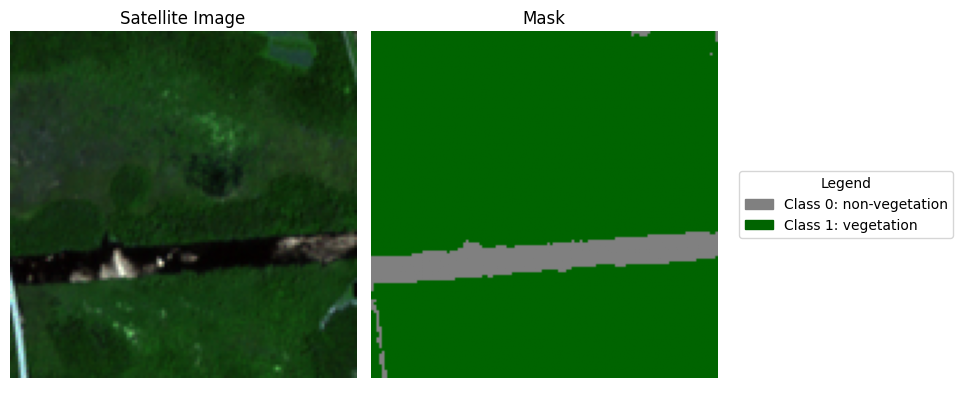

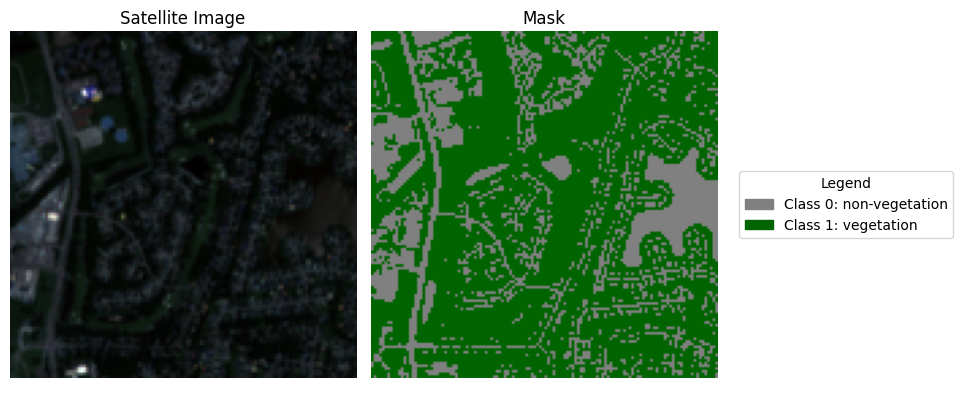

Data Shapes:
--------------------
X_train: (214, 128, 128, 3)
X_val:   (46, 128, 128, 3)
X_test:  (46, 128, 128, 3)
--------------------
y_train: (214, 128, 128, 1)
y_val:   (46, 128, 128, 1)
y_test:  (46, 128, 128, 1)
--------------------
Reading images and masks from SLMO_8R_1 and SLMO_8R_1_masks
|████████████████████████████████████████| 100.00%
Finished reading images
Reading images and masks from SLMO_9R_2 and SLMO_9R_2_masks
|████████████████████████████████████████| 100.00%
Finished reading images
Reading images and masks from SLMO_9R_3 and SLMO_9R_3_masks
|████████████████████████████████████████| 100.00%
Finished reading images
Image data shape is:  (757, 128, 128, 3)
Mask data shape is:  (757, 128, 128, 1)
Max pixel value in image is:  1.0
Min pixel value in image is:  0.0
Labels in the mask are :  [0. 1.]
Number of non-vegetation pixels: 4708715 (37.97%)
Number of vegetation pixels: 7693973 (62.03%)


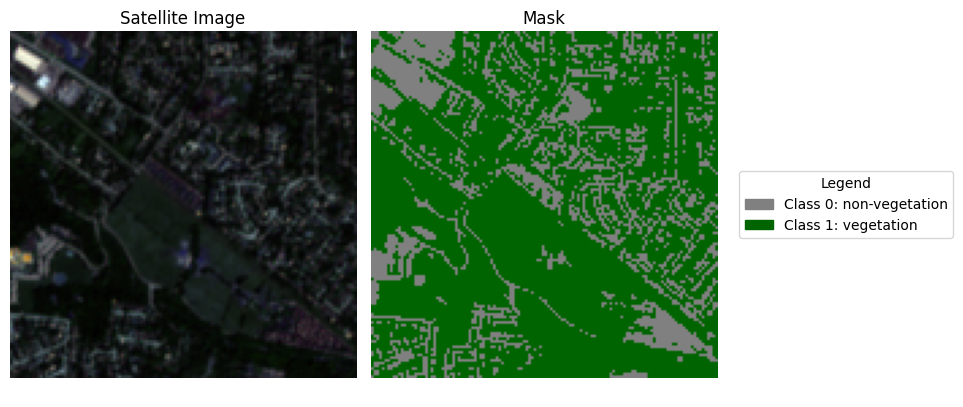

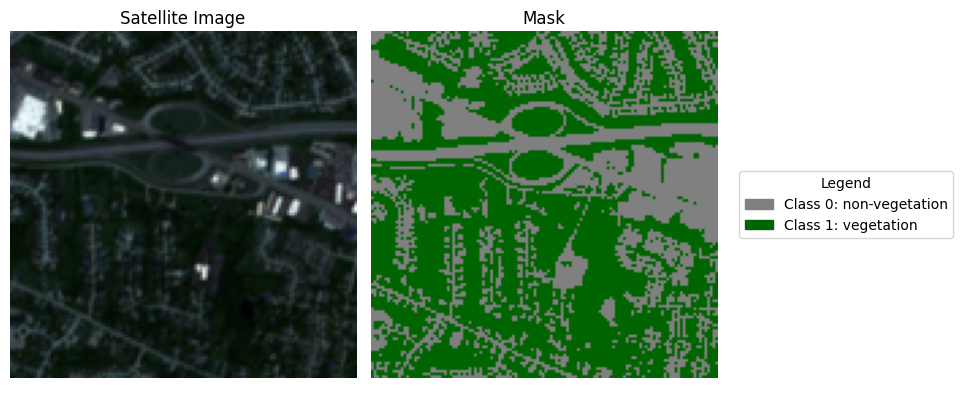

Data Shapes:
--------------------
X_train: (971, 128, 128, 3)
X_val:   (46, 128, 128, 3)
X_test:  (46, 128, 128, 3)
--------------------
y_train: (971, 128, 128, 1)
y_val:   (46, 128, 128, 1)
y_test:  (46, 128, 128, 1)
--------------------
Steps per epoch: 120
Validation steps: 2


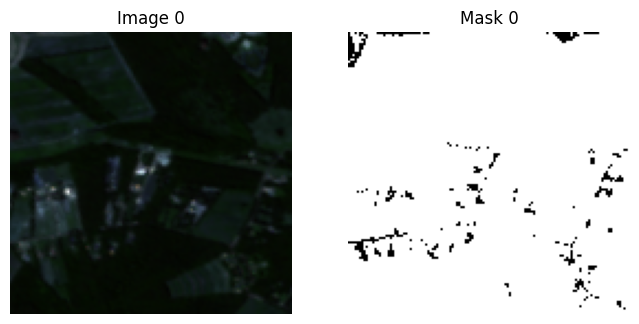

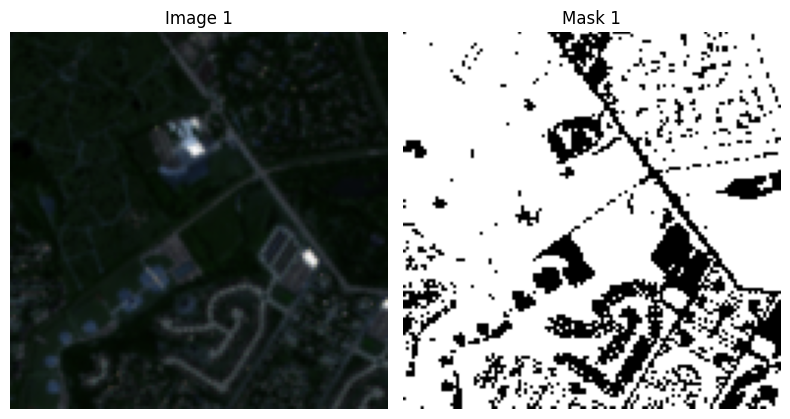

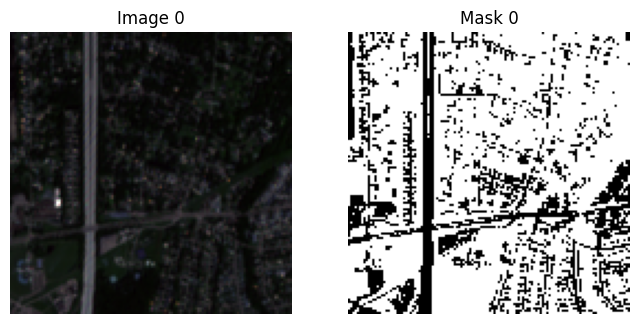

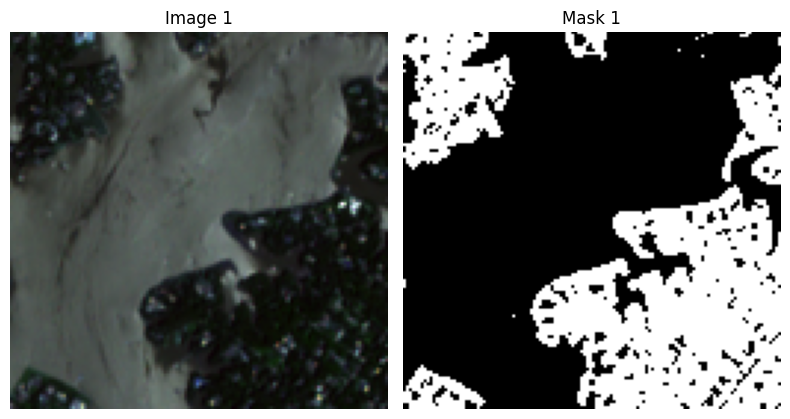

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 128, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 64, 64, 128)    │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 64, 64, 128)    │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

None


In [7]:
# End-to-end U-Net model training

# --- Import packages and functions ---
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.losses import BinaryFocalCrossentropy
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint

# from focal_loss import BinaryFocalLoss
# from tensorflow.keras.losses import SparseCategoricalCrossentropy
# from tensorflow.keras.losses import CategoricalFocalCrossentropy
# from keras.callbacks import EarlyStopping

# Track experiment with MLflow
import dagshub
import mlflow
dagshub.init(repo_name="omdena-frankfurt-ugs-unet", repo_owner="chengzwk")
mlflow.tensorflow.autolog()


class LRFinder(tf.keras.callbacks.Callback):
    def __init__(self, min_lr=1e-8, max_lr=1e-1, steps=100):
        super().__init__()
        self.min_lr = min_lr
        self.max_lr = max_lr
        self.steps = steps
        self.lr_values = np.logspace(np.log10(min_lr), np.log10(max_lr), steps)
        self.losses = []
        self.step = 0

    def on_train_begin(self, logs=None):
        """ Set initial learning rate before training starts """
        # tf.keras.backend.set_value(self.model.optimizer.learning_rate, self.lr_values[0])
        self.model.optimizer.learning_rate.assign(self.lr_values[0])

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        loss = logs.get("loss")
        self.losses.append(loss)

        if self.step < self.steps - 1:
            # tf.keras.backend.set_value(self.model.optimizer.learning_rate, self.lr_values[self.step])
            self.model.optimizer.learning_rate.assign(self.lr_values[0])
            self.step += 1
        else:
            self.model.stop_training = True  # Stop after reaching max steps

    def plot_lr_finder(self):
        """ Plot Learning Rate vs. Loss, ignoring the first few noisy values """
        plt.figure(figsize=(8, 6))
        skip_start = 5  # Skip first 5 points to remove noise
        plt.semilogx(self.lr_values[skip_start:len(self.losses)], self.losses[skip_start:])
        plt.xlabel("Learning Rate")
        plt.ylabel("Loss")
        plt.title("LR Finder: Optimal Learning Rate")
        plt.grid(True)
        plt.show()

class LrLoggingCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []
        self.epochs = []

    def on_epoch_begin(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        self.lrs.append(lr)
        self.epochs.append(epoch)

    def on_train_end(self, logs=None):
        plt.figure(figsize=(6, 4))
        plt.semilogy(self.epochs, self.lrs, marker='o')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Schedule")
        plt.grid()
        plt.show()

class PredictionCallback(Callback):
    def __init__(self, model, X_test, y_test, result_dir, interval=5):
        super().__init__()
        self.X_test = X_test
        self.y_test = y_test
        self.result_dir = result_dir
        self.interval = interval  # Run every 'interval' epochs

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            y_pred, y_pred_thresholded = predict(self.model, X_test)
            visualize_predictions(self.X_test, self.y_test, y_pred_thresholded, self.result_dir, title=f"Epoch {epoch+1} Predictions")

def lr_schedule(epoch, lr):
    if epoch % 10 == 0 and epoch >= 200:
          return lr * float(tf.math.exp(-0.1))
    return lr

# decay_rate = 0.1  # Controls rate of decay
# decay_steps = 20  # Number of epochs before LR reduces significantly
# return lr * np.exp(-decay_rate * (epoch / decay_steps))  # Now using both variables


# --- Data Loading and Preprocessing ---

data_dir = "/content/drive/MyDrive/Omdena/urban-green-frankfurt/MULC"
# data_dir = "/content/drive/MyDrive/MULC"
# data_dir = os.path.expanduser("~/Documents/Omdena/FrankfurtGermanyChapter_UrbanGreenSpaceMappping/MULC")
image_dir = 'VBWVA_8R'
# subset_size = 10
image_dataset, mask_dataset = read_file(
    data_dir,
    image_dir,
    multiclass=False,
#    subset_size=subset_size
)

# Print statistics of the dataset and visually inspect the dataset
show_statistics(image_dataset, mask_dataset)
inspect_dataset(image_dataset, mask_dataset)

# Train-validation-test split
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(image_dataset, mask_dataset)
del image_dataset, mask_dataset
formatted_print_shapes(X_train, X_val, X_test, y_train, y_val, y_test)

# Load the St. Louis dataset
stl_image_dirs = ['SLMO_8R_1', 'SLMO_9R_2', 'SLMO_9R_3']
stl_image_dataset = []
stl_mask_dataset = []
for stl_image_dir in stl_image_dirs:
    temp_image_dataset, temp_mask_dataset = read_file(
        data_dir,
        stl_image_dir,
        multiclass=False
    )
    stl_image_dataset.append(temp_image_dataset)
    stl_mask_dataset.append(temp_mask_dataset)
stl_image_dataset = np.concatenate(stl_image_dataset, axis=0)
stl_mask_dataset = np.concatenate(stl_mask_dataset, axis=0)
del temp_image_dataset, temp_mask_dataset

# Print statistics of the dataset and visually inspect the dataset
show_statistics(stl_image_dataset, stl_mask_dataset)
inspect_dataset(stl_image_dataset, stl_mask_dataset)

# Merge St. Louis data with training set only
X_train_expanded = np.concatenate((X_train, stl_image_dataset), axis=0)
y_train_expanded = np.concatenate((y_train, stl_mask_dataset), axis=0)

# Shuffle the expanded training set
shuffle_idx = np.random.permutation(len(X_train_expanded))
X_train_expanded, y_train_expanded = X_train_expanded[shuffle_idx], y_train_expanded[shuffle_idx]

# Print expanded dataset shapes to verify
formatted_print_shapes(X_train_expanded, X_val, X_test, y_train_expanded, y_val, y_test)

# --- Data Augmentation ---

batch_size = 16
augmentation_factor = 2  # Can adjust this value
steps_per_epoch = augmentation_factor * (len(X_train_expanded) // batch_size)
validation_steps = len(X_val)//batch_size
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
image_generator, valid_img_generator, mask_generator, valid_mask_generator = \
    get_data_generators(X_train_expanded, X_val, y_train_expanded, y_val, use_augmentation=True, batch_size=batch_size)

# Combine image-mask generators
train_generator = my_image_mask_generator(image_generator, mask_generator)
validation_generator = my_image_mask_generator(valid_img_generator, valid_mask_generator)

# Inspect generators
inspect_generator(train_generator)
inspect_generator(validation_generator)

# --- Model Training ---
# Build model
model = unet_model(input_shape=(128, 128, 3), from_logits=True, n_filters=64, use_dropout=False)
print(model.summary())

# Compile model
model.compile(
    # optimizer=Adam(learning_rate=1e-4),
    optimizer=AdamW(learning_rate=1e-3, weight_decay=5e-5),
    loss=BinaryFocalCrossentropy(from_logits=True),  # Pixel-wise binary focal cross-entropy loss
    # loss=BinaryCrossentropy(from_logits=True),  # Pixel-wise binary cross-entropy loss
    metrics = ['accuracy',
               tf.keras.metrics.Precision(thresholds=0),
               tf.keras.metrics.Recall(thresholds=0),
               tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.0),
               tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.0)
               ]
)

# Select a fixed test batch for visualization
num_samples_to_visualize = 2
X_test_fixed = X_test[:num_samples_to_visualize]
y_test_fixed = y_test[:num_samples_to_visualize]

# Create a new directory for training results in Google Drive
# Save model, training history, prediction and evaluation results to this directory
experiment_label = 'experiment09_leave_it_training_lrscheduler_modelcheckpoint'
result_dir = os.path.join('/content/drive/My Drive/finetuning_experiment_results', experiment_label)
history_path = os.path.join(result_dir, 'unet_training_history.pkl')
model_path = os.path.join(result_dir, 'best_model_unet.keras')
os.makedirs(result_dir, exist_ok=True)


# Initialize the LR finder
lr_finder = LRFinder(min_lr=1e-8, max_lr=1e-1, steps=100)

# Run training for a few epochs with LR finder
with mlflow.start_run():
    print("\nStart Model Training with LR finder...")

    model.fit(
        train_generator,
        # steps_per_epoch=min(200, steps_per_epoch),
        steps_per_epoch=200,
        epochs=1,  # Only run for one epoch to test LR range
        callbacks=[lr_finder]
    )

# Plot LR vs. Loss
lr_finder.plot_lr_finder()


Start Model Training with learning rate scheduler...


2025/03/29 23:17:07 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'generator'>. Dataset logging skipped.
2025/03/29 23:17:07 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'generator'>. Dataset logging skipped.



Epoch 1: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 1/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.6497 - binary_io_u: 0.5786 - binary_io_u_1: 0.6469 - loss: 0.1404 - precision: 0.8129 - recall: 0.7596
Epoch 1: val_accuracy improved from -inf to 0.33445, saving model to /content/drive/My Drive/finetuning_experiment_results/experiment09_leave_it_training_lrscheduler_modelcheckpoint/best_model_unet.keras


120/120 ━━━━━━━━━━━━━━━━━━━━ 119s 676ms/step - accuracy: 0.6502 - binary_io_u: 0.5789 - binary_io_u_1: 0.6472 - loss: 0.1402 - precision: 0.8130 - recall: 0.7600 - val_accuracy: 0.3345 - val_binary_io_u: 0.1947 - val_binary_io_u_1: 0.0516 - val_loss: 0.2750 - val_precision: 0.8348 - val_recall: 0.0521 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 2/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.7476 - binary_io_u: 0.6548 - binary_io_u_1: 0.7279 - loss: 0.1068 - precision: 0.8453 - recall: 0.8399
Epoch 2: val_accuracy did not improve from 0.33445


120/120 ━━━━━━━━━━━━━━━━━━━━ 55s 461ms/step - accuracy: 0.7476 - binary_io_u: 0.6548 - binary_io_u_1: 0.7279 - loss: 0.1068 - precision: 0.8453 - recall: 0.8399 - val_accuracy: 0.3330 - val_binary_io_u: 0.4591 - val_binary_io_u_1: 0.4580 - val_loss: 0.1650 - val_precision: 0.9488 - val_recall: 0.4696 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.0010000000474974513.
Epoch 3/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7504 - binary_io_u: 0.6581 - binary_io_u_1: 0.7350 - loss: 0.1047 - precision: 0.8434 - recall: 0.8512
Epoch 3: val_accuracy improved from 0.33445 to 0.34962, saving model to /content/drive/My Drive/finetuning_experiment_results/experiment09_leave_it_training_lrscheduler_modelcheckpoint/best_model_unet.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.7504 - binary_io_u: 0.6581 - binary_io_u_1: 0.7350 - loss: 0.1047 - precision: 0.8435 - recall: 0.8511 - val_accuracy: 0.3496 - val_binary_io_u: 0.3227 - val

...

120/120 ━━━━━━━━━━━━━━━━━━━━ 62s 517ms/step - accuracy: 0.8416 - binary_io_u: 0.7723 - binary_io_u_1: 0.8254 - loss: 0.0698 - precision: 0.8996 - recall: 0.9092 - val_accuracy: 0.8156 - val_binary_io_u: 0.7168 - val_binary_io_u_1: 0.8026 - val_loss: 0.0855 - val_precision: 0.8815 - val_recall: 0.8997 - learning_rate: 8.1873e-04

Epoch 217: LearningRateScheduler setting learning rate to 0.0008187306812033057.
Epoch 217/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8415 - binary_io_u: 0.7750 - binary_io_u_1: 0.8246 - loss: 0.0694 - precision: 0.9016 - recall: 0.9061
Epoch 217: val_accuracy did not improve from 0.84017
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - accuracy: 0.8415 - binary_io_u: 0.7750 - binary_io_u_1: 0.8246 - loss: 0.0694 - precision: 0.9016 - recall: 0.9061 - val_accuracy: 0.8313 - val_binary_io_u: 0.7050 - val_binary_io_u_1: 0.8030 - val_loss: 0.0867 - val_precision: 0.8607 - val_recall: 0.9229 - learning_rate: 8.1873e-04

Epoch 218: LearningRateSchedul

120/120 ━━━━━━━━━━━━━━━━━━━━ 55s 465ms/step - accuracy: 0.8422 - binary_io_u: 0.7737 - binary_io_u_1: 0.8241 - loss: 0.0696 - precision: 0.8992 - recall: 0.9080 - val_accuracy: 0.8210 - val_binary_io_u: 0.7233 - val_binary_io_u_1: 0.8072 - val_loss: 0.0851 - val_precision: 0.8849 - val_recall: 0.9019 - learning_rate: 7.4082e-04

Epoch 226: LearningRateScheduler setting learning rate to 0.000740818097256124.
Epoch 226/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8442 - binary_io_u: 0.7764 - binary_io_u_1: 0.8286 - loss: 0.0686 - precision: 0.9028 - recall: 0.9098
Epoch 226: val_accuracy did not improve from 0.84017
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - accuracy: 0.8442 - binary_io_u: 0.7764 - binary_io_u_1: 0.8286 - loss: 0.0686 - precision: 0.9028 - recall: 0.9097 - val_accuracy: 0.8093 - val_binary_io_u: 0.7187 - val_binary_io_u_1: 0.8026 - val_loss: 0.0867 - val_precision: 0.8852 - val_recall: 0.8959 - learning_rate: 7.4082e-04

Epoch 227: LearningRateSchedule

120/120 ━━━━━━━━━━━━━━━━━━━━ 54s 456ms/step - accuracy: 0.8453 - binary_io_u: 0.7800 - binary_io_u_1: 0.8284 - loss: 0.0675 - precision: 0.9030 - recall: 0.9093 - val_accuracy: 0.8292 - val_binary_io_u: 0.7185 - val_binary_io_u_1: 0.8075 - val_loss: 0.0849 - val_precision: 0.8755 - val_recall: 0.9123 - learning_rate: 4.9659e-04

Epoch 264: LearningRateScheduler setting learning rate to 0.0004965850966982543.
Epoch 264/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8438 - binary_io_u: 0.7762 - binary_io_u_1: 0.8261 - loss: 0.0686 - precision: 0.9003 - recall: 0.9093
Epoch 264: val_accuracy did not improve from 0.84017
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.8438 - binary_io_u: 0.7762 - binary_io_u_1: 0.8262 - loss: 0.0686 - precision: 0.9003 - recall: 0.9093 - val_accuracy: 0.8306 - val_binary_io_u: 0.7153 - val_binary_io_u_1: 0.8052 - val_loss: 0.0857 - val_precision: 0.8742 - val_recall: 0.9107 - learning_rate: 4.9659e-04

Epoch 265: LearningRateSchedul

120/120 ━━━━━━━━━━━━━━━━━━━━ 54s 455ms/step - accuracy: 0.8469 - binary_io_u: 0.7815 - binary_io_u_1: 0.8327 - loss: 0.0660 - precision: 0.9051 - recall: 0.9123 - val_accuracy: 0.8284 - val_binary_io_u: 0.7192 - val_binary_io_u_1: 0.8068 - val_loss: 0.0848 - val_precision: 0.8782 - val_recall: 0.9084 - learning_rate: 2.2313e-04

Epoch 344: LearningRateScheduler setting learning rate to 0.0002231299295090139.
Epoch 344/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8508 - binary_io_u: 0.7869 - binary_io_u_1: 0.8359 - loss: 0.0645 - precision: 0.9073 - recall: 0.9140
Epoch 344: val_accuracy did not improve from 0.84017


120/120 ━━━━━━━━━━━━━━━━━━━━ 54s 453ms/step - accuracy: 0.8508 - binary_io_u: 0.7869 - binary_io_u_1: 0.8359 - loss: 0.0645 - precision: 0.9073 - recall: 0.9140 - val_accuracy: 0.8246 - val_binary_io_u: 0.7202 - val_binary_io_u_1: 0.8064 - val_loss: 0.0845 - val_precision: 0.8807 - val_recall: 0.9053 - learning_rate: 2.2313e-04

Epoch 345: LearningRateScheduler setting learning rate to 0.0002231299295090139.
Epoch 345/400
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.8505 - binary_io_u: 0.7860 - binary_io_u_1: 0.8350 - loss: 0.0650 - precision: 0.9064 - recall: 0.9138
Epoch 345: val_accuracy did not improve from 0.84017
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 118ms/step - accuracy: 0.8505 - binary_io_u: 0.7860 - binary_io_u_1: 0.8350 - loss: 0.0650 - precision: 0.9064 - recall: 0.9138 - val_accuracy: 0.8264 - val_binary_io_u: 0.7204 - val_binary_io_u_1: 0.8065 - val_loss: 0.0851 - val_precision: 0.8809 - val_recall: 0.9051 - learning_rate: 2.2313e-04

Epoch 346: LearningRateSchedul

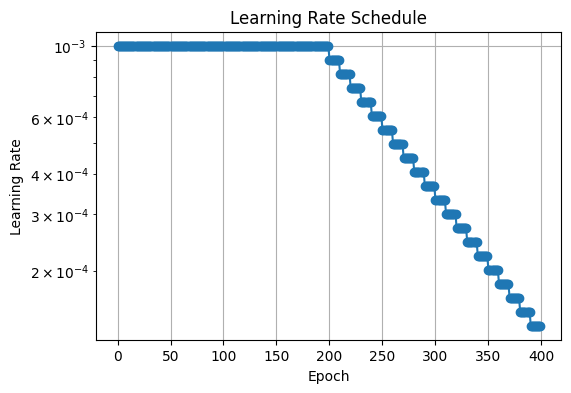

2025/03/30 01:16:29 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'generator'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/03/30 01:16:29 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/03/30 01:16:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run fearless-moth-301 at: https://dagshub.com/chengzwk/omdena-frankfurt-ugs-unet.mlflow/#/experiments/0/runs/bd88fea977e34be9a6f4165a9639a547
🧪 View experiment at: https://dagshub.com/chengzwk/omdena-frankfurt-ugs-unet.mlflow/#/experiments/0


In [8]:
# Callbacks
# Add learning rate scheduler as a callback
lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)

# ModelCheckpoint to save best model
model_checkpoint_callback = ModelCheckpoint(
    filepath=model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Train model
epochs = 400  # Set epochs and early stopping

with mlflow.start_run():
    print("\nStart Model Training with learning rate scheduler...")

    history_2 = model.fit(
        train_generator,
        validation_data=validation_generator,
        batch_size=batch_size,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        epochs = epochs,
        callbacks=[lr_callback, LrLoggingCallback(), model_checkpoint_callback,
                   PredictionCallback(model, X_test_fixed, y_test_fixed, result_dir, interval=10)]
    )

# Save training history
with open(history_path, 'wb') as file:
    pickle.dump(history_2.history, file)


Model Evaluation
--------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Loss: 0.0934
Accuracy: 0.8157
Precision: 0.8659
Recall: 0.8823
F1 Score: 0.8740
Mean IoU: 0.7166
IoU for class 1: 0.7762
AUC: 0.8316


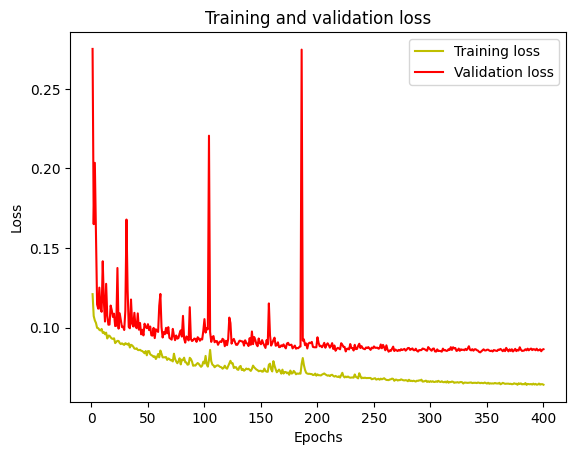

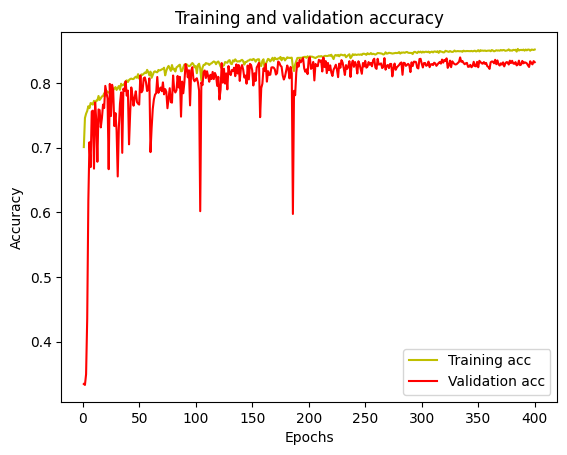

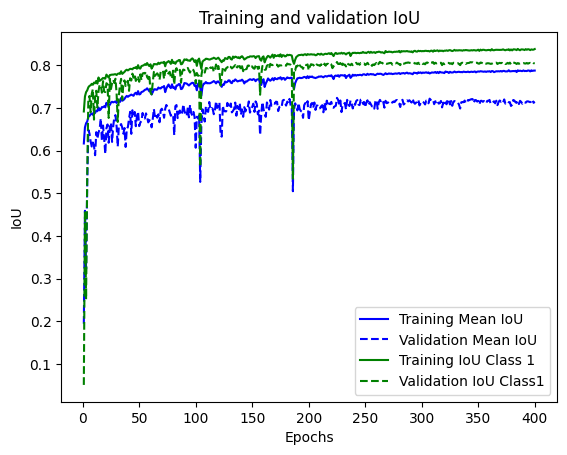

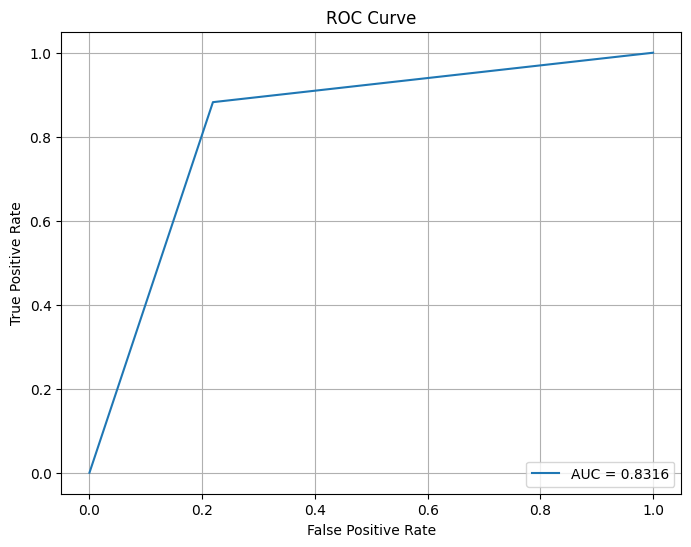

In [9]:
def plot_accuracy(history_2, result_dir):
    loss = history_2.history['loss']
    val_loss = history_2.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure()
    plt.plot(epochs, loss, 'y', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(os.path.join(result_dir, "Loss.png"))

    acc = history_2.history['accuracy']
    val_acc = history_2.history['val_accuracy']
    plt.figure()
    plt.plot(epochs, acc, 'y', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(os.path.join(result_dir, "Accuracy.png"))

    mean_iou = history_2.history['binary_io_u']
    val_mean_iou = history_2.history['val_binary_io_u']
    iou_class1 = history_2.history['binary_io_u_1']
    val_iou_class1 = history_2.history['val_binary_io_u_1']
    plt.figure()
    plt.plot(epochs, mean_iou, 'b-', label='Training Mean IoU')
    plt.plot(epochs, val_mean_iou, 'b--', label='Validation Mean IoU')
    plt.plot(epochs, iou_class1, 'g-', label='Training IoU Class 1')
    plt.plot(epochs, val_iou_class1, 'g--', label='Validation IoU Class1')
    plt.title('Training and validation IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()
    plt.savefig(os.path.join(result_dir, "IoU.png"))


# Plot the training and validation accuracy and loss at each epoch
plot_accuracy(history_2, result_dir)

# --- Model Prediction and Evaluation ---
run_evaluation(model, X_test, y_test, result_dir)

## Conclusion

## Commit notebook to dagshub

In [10]:
commit_message = "Experiment 09: rain for 300 epoches with a large learning rate(1e-3) and lr scheduler, save best model."

In [ ]:
from dagshub.notebook import save_notebook

repo = "chengzwk/omdena-frankfurt-ugs-unet"
branch = "fine-tuning"
notebook_path = "unet-from-scratch.ipynb"

save_notebook(
    repo=repo,
    branch=branch,
    path=notebook_path,
    commit_message=commit_message,
    versioning="git"
    )